# 03b — Auditoría de calidad de señales ECG

**Propósito:** Inspeccionar los archivos `.npy` descargados en `data/raw/vitaldb_waveforms/` *antes* de construir ventanas y features en el notebook 04.  
Ningún modelo se entrena aquí. Los outputs son reportes CSV y listas de `valid_cases` que el notebook 04 puede consumir directamente.

## ¿Por qué hacer esto antes del feature engineering?

| Problema | Consecuencia en notebook 04 |
|---|---|
| Archivo vacío (`n_samples == 0`) | `build_windows_for_case` silenciosamente retorna 0 ventanas |
| NaN / Inf en la señal | Features estadísticas (media, std, kurtosis…) se propagan como NaN |
| Varianza cero | Features como `zero_crossing_rate`, `skew`, `kurtosis` son indefinidas |
| Señal más corta que la última anotación | Las ventanas centradas en los últimos latidos quedan truncadas o se descartan |
| Caso sin archivo `.npy` | El join con anotaciones falla silenciosamente |

Identificar estos casos con antelación permite decidir explícitamente qué entra al pipeline, en vez de descubrirlo como NaN en la matriz de features.

## 1. Setup: imports y rutas

In [14]:
import sys
from pathlib import Path

# Detectar robustamente la raíz del repo.
# Funciona si el notebook se abre desde notebooks/, desde la raíz o desde una subcarpeta.
CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = CURRENT_DIR
for candidate in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (candidate / "src").exists() and (candidate / "requirements.txt").exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("CURRENT_DIR:", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("¿Existe src?:", (PROJECT_ROOT / "src").exists())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

from src import config
from src.data_loading import load_metadata, load_all_annotations
from src.utils import get_logger, ensure_dir

logger = get_logger("nb03b")

# Directorios de salida
ensure_dir(config.PROCESSED_DIR)

sns.set_theme(style="whitegrid", palette="muted")
logger.info("PROJECT_ROOT = %s", PROJECT_ROOT)
logger.info("Waveform dir = %s", config.VITALDB_WAVEFORMS_DIR)
logger.info("Processed dir = %s", config.PROCESSED_DIR)

2026-05-19 19:17:02 | nb03b | INFO | PROJECT_ROOT = C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml
2026-05-19 19:17:02 | nb03b | INFO | Waveform dir = C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\data\raw\vitaldb_waveforms
2026-05-19 19:17:02 | nb03b | INFO | Processed dir = C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\data\processed


CURRENT_DIR: C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\notebooks
PROJECT_ROOT: C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml
¿Existe src?: True


## 2. Auditoría de archivos `.npy`

Para cada archivo se registran:
- **dimensiones** (n_samples, duración)
- **integridad** (NaN, Inf, varianza cero)
- **estadísticos básicos** de la señal cruda
- **errores de carga** (archivo corrupto, formato inesperado)

In [15]:
FS = config.DEFAULT_ECG_FS_HZ  # Hz

waveform_files = sorted(config.VITALDB_WAVEFORMS_DIR.glob("case_*.npy"))
logger.info("Archivos .npy encontrados: %d", len(waveform_files))

records = []

for fpath in tqdm(waveform_files, desc="Auditando señales"):
    # Extraer case_id desde el nombre: case_<id>.npy
    try:
        case_id = int(fpath.stem.split("_")[1])
    except (IndexError, ValueError):
        case_id = fpath.stem

    row = dict(
        case_id=case_id,
        file_name=fpath.name,
        file_size_mb=fpath.stat().st_size / (1024**2),
        original_shape=None,
        dtype=None,
        n_samples=0,
        duration_seconds=0.0,
        duration_minutes=0.0,
        is_empty=True,
        nan_count=0,
        inf_count=0,
        nan_pct=0.0,
        inf_pct=0.0,
        signal_min=np.nan,
        signal_max=np.nan,
        signal_mean=np.nan,
        signal_std=np.nan,
        zero_variance=True,
        load_error=None,
    )

    try:
        sig = np.load(fpath)
        row["original_shape"] = str(sig.shape)
        row["dtype"] = str(sig.dtype)

        sig = np.asarray(sig).ravel()  # aplanar por si tiene shape (N,1), etc.
        n = len(sig)

        row["n_samples"] = n
        row["duration_seconds"] = n / FS
        row["duration_minutes"] = n / FS / 60
        row["is_empty"] = n == 0

        if n > 0:
            finite_mask = np.isfinite(sig)
            nan_mask = np.isnan(sig)
            inf_mask = np.isinf(sig)

            row["nan_count"] = int(nan_mask.sum())
            row["inf_count"] = int(inf_mask.sum())
            row["nan_pct"] = float(nan_mask.mean()) * 100
            row["inf_pct"] = float(inf_mask.mean()) * 100

            valid = sig[finite_mask]
            if len(valid) > 0:
                signal_std = float(valid.std())
                row["signal_min"] = float(valid.min())
                row["signal_max"] = float(valid.max())
                row["signal_mean"] = float(valid.mean())
                row["signal_std"] = signal_std
                row["zero_variance"] = np.isclose(signal_std, 0.0)

    except Exception as exc:
        row["load_error"] = str(exc)

    records.append(row)

quality_df = pd.DataFrame(records)
logger.info("Auditoría completada: %d registros", len(quality_df))

quality_df.head()

2026-05-19 19:17:02 | nb03b | INFO | Archivos .npy encontrados: 482


Auditando señales:   0%|          | 0/482 [00:00<?, ?it/s]

2026-05-19 19:18:09 | nb03b | INFO | Auditoría completada: 482 registros


,case_id,file_name,file_size_mb,original_shape,dtype,n_samples,duration_seconds,duration_minutes,is_empty,nan_count,inf_count,nan_pct,inf_pct,signal_min,signal_max,signal_mean,signal_std,zero_variance,load_error
0,1001,case_1001.npy,35.657059,"(4673626,)",float64,4673626,9347.252,155.787533,False,1631,0,0.034898,0.0,-4.95626,5.14543,-0.022304,0.258668,False,None
1,1002,case_1002.npy,37.254578,"(4883016,)",float64,4883016,9766.032,162.767200,False,299,0,0.006123,0.0,-4.95626,5.14543,0.073027,0.350086,False,None
2,1018,case_1018.npy,98.162582,"(12866350,)",float64,12866350,25732.700,428.878333,False,21800,0,0.169434,0.0,-4.95626,5.14543,0.070685,0.179683,False,None
3,1023,case_1023.npy,19.810188,"(2596545,)",float64,2596545,5193.090,86.551500,False,750,0,0.028885,0.0,-4.95626,5.14543,0.035736,0.305798,False,None
4,103,case_103.npy,40.998962,"(5373800,)",float64,5373800,10747.600,179.126667,False,10422,0,0.193941,0.0,-4.95626,5.14543,-0.022957,0.206808,False,None


## 3. Resumen de problemas de calidad

In [16]:
summary_quality = {
    "Total archivos auditados":      len(quality_df),
    "Archivos vacíos (0 muestras)":  int(quality_df["is_empty"].sum()),
    "Errores de carga":              int(quality_df["load_error"].notna().sum()),
    "Con algún NaN":                 int((quality_df["nan_count"] > 0).sum()),
    "Con algún Inf":                 int((quality_df["inf_count"] > 0).sum()),
    "Varianza cero":                 int(quality_df["zero_variance"].sum()),
}

for k, v in summary_quality.items():
    print(f"  {k:<35} {v}")

quality_df.describe()

  Total archivos auditados            482
  Archivos vacíos (0 muestras)        0
  Errores de carga                    0
  Con algún NaN                       482
  Con algún Inf                       0
  Varianza cero                       0


,case_id,file_size_mb,n_samples,duration_seconds,duration_minutes,nan_count,inf_count,nan_pct,inf_pct,signal_min,signal_max,signal_mean,signal_std
count,482.000000,482.000000,4.820000e+02,482.000000,482.000000,4.820000e+02,482.0,482.000000,482.0,482.00000,482.000000,482.000000,482.000000
mean,3207.114108,53.142947,6.965536e+06,13931.072610,232.184543,7.074791e+04,0.0,0.578561,0.0,-4.95626,5.144406,0.039059,0.283828
std,1806.795772,30.417060,3.986825e+06,7973.649816,132.894164,5.392671e+05,0.0,3.385722,0.0,0.00000,0.022489,0.041244,0.108798
min,12.000000,9.594582,1.257565e+06,2515.130000,41.918833,1.000000e+00,0.0,0.000017,0.0,-4.95626,4.651700,-0.104779,0.091110
25%,1742.250000,29.658382,3.887368e+06,7774.735000,129.578917,4.682500e+02,0.0,0.010790,0.0,-4.95626,5.145430,0.007530,0.216140
50%,3168.500000,47.387249,6.211126e+06,12422.251000,207.037517,1.595000e+03,0.0,0.032606,0.0,-4.95626,5.145430,0.043215,0.261068
75%,4743.500000,67.218618,8.810463e+06,17620.925500,293.682092,1.006625e+04,0.0,0.132029,0.0,-4.95626,5.145430,0.072169,0.320648
max,6374.000000,225.685997,2.958110e+07,59162.198000,986.036633,8.000822e+06,0.0,37.406913,0.0,-4.95626,5.145430,0.157899,1.305784


## 4. Carga de anotaciones

Se usa `load_all_annotations()` del módulo `src.data_loading`, que inyecta `case_id` desde el nombre del archivo y no requiere configuración adicional.

In [17]:
annotations = load_all_annotations()  # carga todos los CSV de PhysioNet

logger.info(
    "Anotaciones cargadas: %d filas, %d casos únicos",
    len(annotations),
    annotations[config.CASE_ID_COLUMN].nunique(),
)
annotations.head(3)

2026-05-19 19:18:10 | nb03b | INFO | Anotaciones cargadas: 676250 filas, 482 casos únicos


,time_second,beat_type,rhythm_label,bad_signal_quality,bad_signal_quality_label,case_id,caseid
0,4993.494444,N,N,False,NaN,1001,NaN
1,4994.586111,N,N,False,NaN,1001,NaN
2,4995.672222,N,N,False,NaN,1001,NaN


## 5. Comparación señal vs. anotaciones

**`signal_covers_annotations`**: `True` cuando la duración de la señal descargada alcanza o supera el tiempo del último latido anotado.  
**`missing_seconds_at_end`**: segundos faltantes al final; 0 si la cobertura es completa.  
**`coverage_ratio`**: `duration_seconds / max_annotation_time`. Un valor < 1 indica que hay latidos anotados fuera del segmento descargado.

In [18]:
ann_stats = (
    annotations
    .groupby(config.CASE_ID_COLUMN)[config.BEAT_TIME_COLUMN]
    .agg(
        n_annotations="count",
        min_annotation_time="min",
        max_annotation_time="max",
    )
    .reset_index()
)

quality_for_join = quality_df[
    [
        "case_id", "file_name", "n_samples", "duration_seconds", "duration_minutes",
        "is_empty", "nan_count", "inf_count", "zero_variance", "load_error"
    ]
].copy()

# Join externo para identificar:
# - casos con anotaciones pero sin señal .npy
# - señales .npy sin anotaciones
coverage_df = ann_stats.merge(
    quality_for_join,
    on="case_id",
    how="outer",
)

coverage_df["has_annotations"] = coverage_df["n_annotations"].notna()
coverage_df["has_npy"] = coverage_df["file_name"].notna()

coverage_df["coverage_ratio_raw"] = (
    coverage_df["duration_seconds"] / coverage_df["max_annotation_time"]
)

# Para gráficos y filtros flexibles se recorta en 1.0.
# El ratio crudo se conserva por si la señal es más larga que la última anotación.
coverage_df["coverage_ratio"] = coverage_df["coverage_ratio_raw"].clip(upper=1.0)

coverage_df["signal_covers_annotations"] = (
    coverage_df["has_annotations"]
    & coverage_df["has_npy"]
    & coverage_df["duration_seconds"].notna()
    & coverage_df["max_annotation_time"].notna()
    & (coverage_df["duration_seconds"] >= coverage_df["max_annotation_time"])
)

coverage_df["missing_seconds_at_end"] = (
    coverage_df["max_annotation_time"] - coverage_df["duration_seconds"]
).clip(lower=0)

coverage_df.loc[~coverage_df["has_annotations"] | ~coverage_df["has_npy"], "missing_seconds_at_end"] = np.nan

# Casos con anotaciones pero sin archivo .npy
missing_npy = set(
    coverage_df.loc[
        coverage_df["has_annotations"] & ~coverage_df["has_npy"],
        "case_id"
    ]
)

logger.info("Casos con anotaciones pero sin .npy: %d", len(missing_npy))
coverage_df.head(5)

2026-05-19 19:18:10 | nb03b | INFO | Casos con anotaciones pero sin .npy: 0


,case_id,n_annotations,min_annotation_time,max_annotation_time,file_name,n_samples,duration_seconds,duration_minutes,is_empty,nan_count,inf_count,zero_variance,load_error,has_annotations,has_npy,coverage_ratio_raw,coverage_ratio,signal_covers_annotations,missing_seconds_at_end
0,12,1183,8642.622222,9692.511111,case_12.npy,15601450,31202.900,520.048333,False,4325130,0,False,None,True,True,3.219279,1.0,True,0.0
1,13,1317,116.163889,1267.502778,case_13.npy,5405150,10810.300,180.171667,False,17314,0,False,None,True,True,8.528818,1.0,True,0.0
2,19,1674,23532.016667,24731.372222,case_19.npy,13787600,27575.200,459.586667,False,2125,0,False,None,True,True,1.114989,1.0,True,0.0
3,42,1162,10150.988889,11343.216667,case_42.npy,7679800,15359.600,255.993333,False,9626,0,False,None,True,True,1.354078,1.0,True,0.0
4,96,1559,16802.016667,18001.741667,case_96.npy,18989301,37978.602,632.976700,False,2541,0,False,None,True,True,2.109718,1.0,True,0.0


## 6. Resumen de cobertura

In [19]:
has_npy = coverage_df["has_npy"]
has_ann = coverage_df["has_annotations"]
has_both = has_npy & has_ann

summary_coverage = {
    "Casos con archivo .npy": int(has_npy.sum()),
    "Casos con anotaciones": int(has_ann.sum()),
    "Casos con .npy y anotaciones": int(has_both.sum()),
    "Casos sin archivo .npy (solo anotaciones)": int((has_ann & ~has_npy).sum()),
    "Archivos .npy sin anotaciones": int((has_npy & ~has_ann).sum()),
    "Señal NO cubre todas las anotaciones": int((has_both & ~coverage_df["signal_covers_annotations"]).sum()),
    "coverage_ratio < 0.95": int((has_both & (coverage_df["coverage_ratio"].fillna(0) < 0.95)).sum()),
    "coverage_ratio >= 0.95": int((has_both & (coverage_df["coverage_ratio"].fillna(0) >= 0.95)).sum()),
    "coverage_ratio == 1.0 (cobertura completa)": int((has_both & (coverage_df["coverage_ratio"].fillna(0) >= 1.0)).sum()),
}

for k, v in summary_coverage.items():
    print(f"  {k:<55} {v}")

coverage_df.loc[has_both, ["duration_seconds", "max_annotation_time", "missing_seconds_at_end", "coverage_ratio"]].describe()

  Casos con archivo .npy                                  482
  Casos con anotaciones                                   482
  Casos con .npy y anotaciones                            482
  Casos sin archivo .npy (solo anotaciones)               0
  Archivos .npy sin anotaciones                           0
  Señal NO cubre todas las anotaciones                    0
  coverage_ratio < 0.95                                   0
  coverage_ratio >= 0.95                                  482
  coverage_ratio == 1.0 (cobertura completa)              482


,duration_seconds,max_annotation_time,missing_seconds_at_end,coverage_ratio
count,482.000000,482.000000,482.0,482.0
mean,13931.072610,5655.965308,0.0,1.0
std,7973.649816,5257.839469,0.0,0.0
min,2515.130000,598.994444,0.0,1.0
25%,7774.735000,2085.562500,0.0,1.0
50%,12422.251000,3732.072222,0.0,1.0
75%,17620.925500,7700.032639,0.0,1.0
max,59162.198000,34767.430556,0.0,1.0


## 7. Visualizaciones

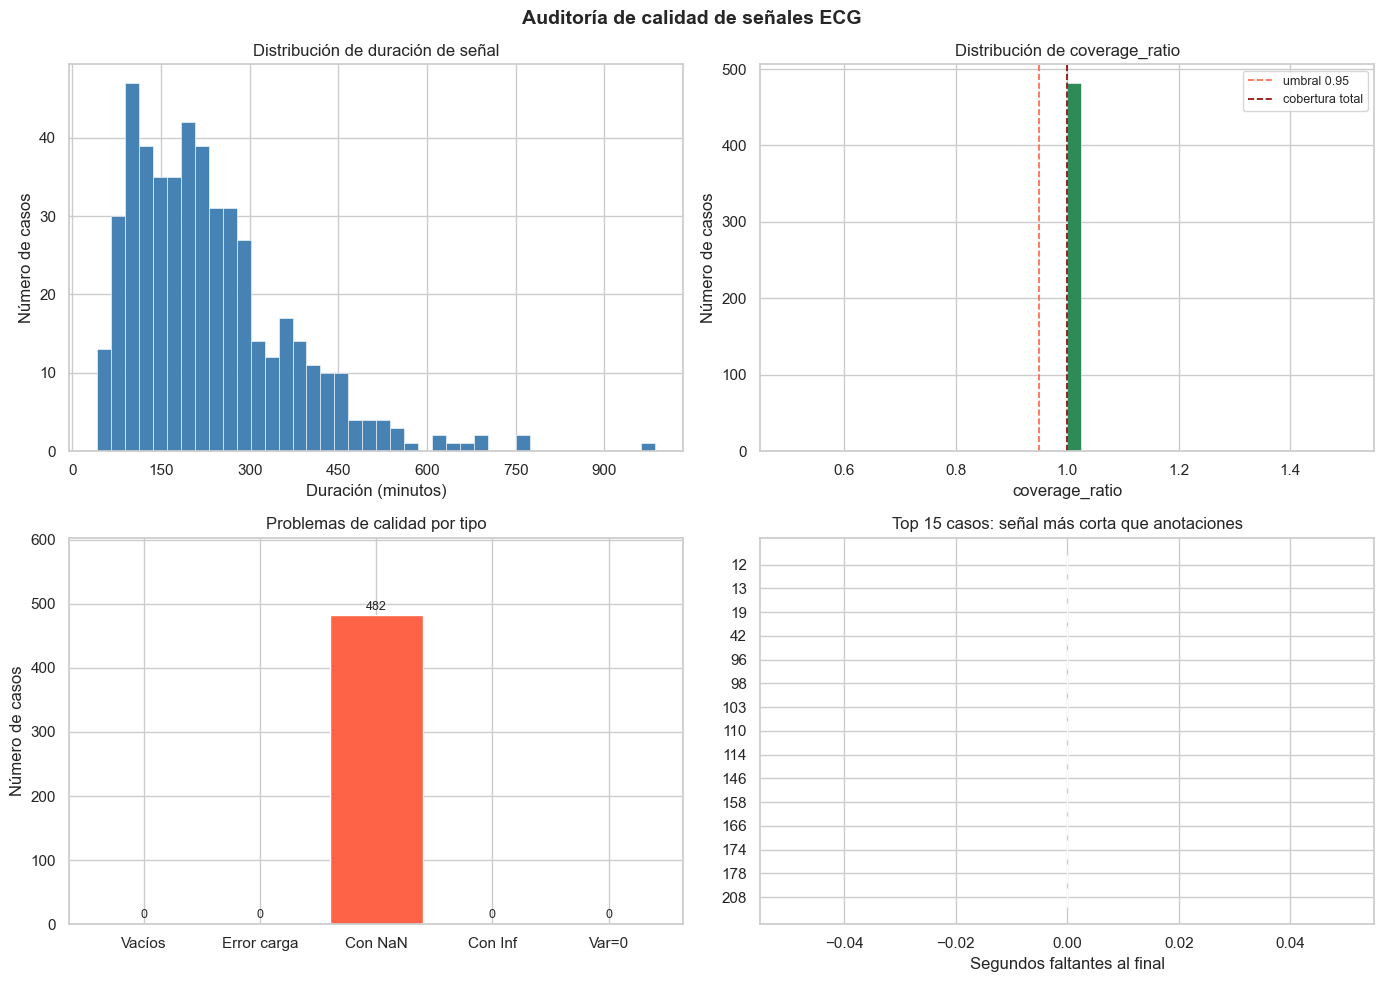

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Auditoría de calidad de señales ECG", fontsize=14, fontweight="bold")

# --- 7.1 Distribución de duración de señales ---
ax = axes[0, 0]
valid_dur = quality_df.loc[quality_df["duration_minutes"] > 0, "duration_minutes"]
ax.hist(valid_dur, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Duración (minutos)")
ax.set_ylabel("Número de casos")
ax.set_title("Distribución de duración de señal")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# --- 7.2 Distribución de coverage_ratio ---
ax = axes[0, 1]
valid_cov = coverage_df["coverage_ratio"].dropna()
ax.hist(valid_cov, bins=40, color="seagreen", edgecolor="white", linewidth=0.4)
ax.axvline(0.95, color="tomato", linestyle="--", linewidth=1.2, label="umbral 0.95")
ax.axvline(1.00, color="darkred", linestyle="--", linewidth=1.2, label="cobertura total")
ax.set_xlabel("coverage_ratio")
ax.set_ylabel("Número de casos")
ax.set_title("Distribución de coverage_ratio")
ax.legend(fontsize=9)

# --- 7.3 Conteo de problemas de calidad ---
ax = axes[1, 0]
problem_labels = ["Vacíos", "Error carga", "Con NaN", "Con Inf", "Var=0"]
problem_counts = [
    int(quality_df["is_empty"].sum()),
    int(quality_df["load_error"].notna().sum()),
    int((quality_df["nan_count"] > 0).sum()),
    int((quality_df["inf_count"] > 0).sum()),
    int(quality_df["zero_variance"].sum()),
]
colors = ["tomato" if c > 0 else "lightgray" for c in problem_counts]
bars = ax.bar(problem_labels, problem_counts, color=colors, edgecolor="white")
ax.bar_label(bars, padding=2, fontsize=9)
ax.set_ylabel("Número de casos")
ax.set_title("Problemas de calidad por tipo")
ax.set_ylim(0, max(problem_counts) * 1.25 + 1)

# --- 7.4 Peores casos por missing_seconds_at_end ---
ax = axes[1, 1]
worst = (
    coverage_df
    .nlargest(15, "missing_seconds_at_end")[["case_id", "missing_seconds_at_end"]]
    .reset_index(drop=True)
)
ax.barh(
    worst["case_id"].astype(str),
    worst["missing_seconds_at_end"],
    color="salmon", edgecolor="white"
)
ax.set_xlabel("Segundos faltantes al final")
ax.set_title("Top 15 casos: señal más corta que anotaciones")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 7.5 Tabla de casos con cobertura incompleta

In [21]:
incomplete = coverage_df[
    coverage_df["has_annotations"]
    & coverage_df["has_npy"]
    & (coverage_df["signal_covers_annotations"] == False)
].sort_values("missing_seconds_at_end", ascending=False)

print(f"Casos con señal incompleta respecto a anotaciones: {len(incomplete)}")

display_cols = [
    "case_id", "duration_seconds", "max_annotation_time",
    "n_annotations", "missing_seconds_at_end", "coverage_ratio"
]

incomplete[display_cols].head(20)

Casos con señal incompleta respecto a anotaciones: 0


,case_id,duration_seconds,max_annotation_time,n_annotations,missing_seconds_at_end,coverage_ratio


### 7.6 Tabla de casos problemáticos por calidad de señal


In [22]:
problematic_quality = quality_df[
    quality_df["is_empty"]
    | quality_df["load_error"].notna()
    | (quality_df["nan_count"] > 0)
    | (quality_df["inf_count"] > 0)
    | quality_df["zero_variance"]
].copy()

print(f"Casos problemáticos por calidad de señal: {len(problematic_quality)}")

problem_cols = [
    "case_id", "file_name", "n_samples", "duration_minutes",
    "is_empty", "nan_count", "inf_count", "signal_std",
    "zero_variance", "load_error"
]

problematic_quality[problem_cols].head(30)

Casos problemáticos por calidad de señal: 482


,case_id,file_name,n_samples,duration_minutes,is_empty,nan_count,inf_count,signal_std,zero_variance,load_error
0,1001,case_1001.npy,4673626,155.787533,False,1631,0,0.258668,False,None
1,1002,case_1002.npy,4883016,162.767200,False,299,0,0.350086,False,None
2,1018,case_1018.npy,12866350,428.878333,False,21800,0,0.179683,False,None
3,1023,case_1023.npy,2596545,86.551500,False,750,0,0.305798,False,None
4,103,case_103.npy,5373800,179.126667,False,10422,0,0.206808,False,None
5,1063,case_1063.npy,7673650,255.788333,False,16891,0,0.201648,False,None
6,1072,case_1072.npy,7940650,264.688333,False,760,0,0.226102,False,None
7,1083,case_1083.npy,14246300,474.876667,False,8734,0,0.157400,False,None
8,1086,case_1086.npy,7677600,255.920000,False,765,0,0.374610,False,None
9,110,case_110.npy,3837585,127.919500,False,588,0,0.272056,False,None


## 8. Guardar reportes CSV

In [23]:
quality_path   = config.PROCESSED_DIR / "waveform_quality_report.csv"
coverage_path  = config.PROCESSED_DIR / "waveform_vs_annotations_report.csv"

quality_df.to_csv(quality_path, index=False)
coverage_df.to_csv(coverage_path, index=False)

logger.info("Reporte de calidad guardado en: %s", quality_path)
logger.info("Reporte de cobertura guardado en: %s", coverage_path)

2026-05-19 19:18:10 | nb03b | INFO | Reporte de calidad guardado en: C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\data\processed\waveform_quality_report.csv
2026-05-19 19:18:10 | nb03b | INFO | Reporte de cobertura guardado en: C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\data\processed\waveform_vs_annotations_report.csv


## 9. Construcción de listas de casos válidos

Se definen dos criterios de inclusión para el notebook 04:

**Criterio estricto** — todos los filtros de calidad, incluyendo cobertura total de anotaciones (`coverage_ratio == 1.0`):
- archivo existe y no está vacío
- sin errores de carga
- sin NaN ni Inf
- sin varianza cero
- `signal_covers_annotations == True`

**Criterio flexible** — igual que el estricto pero acepta `coverage_ratio >= 0.95`.  
Útil cuando la señal termina levemente antes que la última anotación (artefacto de descarga parcial).

In [24]:
# Construir tabla combinada para filtrado.
# Solo pueden ser válidos los casos con señal .npy y con anotaciones.
filter_df = coverage_df.copy()

base_mask = (
    filter_df["has_annotations"]
    & filter_df["has_npy"]
    & ~filter_df["is_empty"].fillna(True)
    & filter_df["load_error"].isna()
    & (filter_df["inf_count"].fillna(1) == 0)
    & ~filter_df["zero_variance"].fillna(True)
)

strict_mask = base_mask & (filter_df["signal_covers_annotations"] == True)
flexible_mask = base_mask & (filter_df["coverage_ratio"].fillna(0) >= 0.95)

valid_strict = (
    filter_df.loc[strict_mask, "case_id"]
    .astype(int)
    .sort_values()
    .reset_index(drop=True)
)

valid_flexible = (
    filter_df.loc[flexible_mask, "case_id"]
    .astype(int)
    .sort_values()
    .reset_index(drop=True)
)

print(f"Casos válidos (criterio estricto):  {len(valid_strict)}")
print(f"Casos válidos (criterio flexible):  {len(valid_flexible)}")
print(f"Diferencia:                         {len(valid_flexible) - len(valid_strict)} casos adicionales con criterio flexible")

Casos válidos (criterio estricto):  482
Casos válidos (criterio flexible):  482
Diferencia:                         0 casos adicionales con criterio flexible


### 9.1 Exportar listas de casos válidos

In [25]:
strict_path   = config.PROCESSED_DIR / "valid_cases_strict.csv"
flexible_path = config.PROCESSED_DIR / "valid_cases_flexible.csv"

valid_strict.to_frame(name="case_id").to_csv(strict_path, index=False)
valid_flexible.to_frame(name="case_id").to_csv(flexible_path, index=False)

logger.info("valid_cases_strict   guardado en: %s  (%d casos)", strict_path,   len(valid_strict))
logger.info("valid_cases_flexible guardado en: %s  (%d casos)", flexible_path, len(valid_flexible))

2026-05-19 19:18:10 | nb03b | INFO | valid_cases_strict   guardado en: C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\data\processed\valid_cases_strict.csv  (482 casos)
2026-05-19 19:18:10 | nb03b | INFO | valid_cases_flexible guardado en: C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\data\processed\valid_cases_flexible.csv  (482 casos)


## 10. Resumen ejecutivo

Consolida todos los contadores en un único bloque para referencia rápida.

In [26]:
print("=" * 60)
print("RESUMEN AUDITORÍA — CALIDAD DE SEÑALES ECG")
print("=" * 60)
print("\n--- Archivos ---")
for k, v in summary_quality.items():
    print(f"  {k:<40} {v}")

print("\n--- Cobertura vs. anotaciones ---")
for k, v in summary_coverage.items():
    print(f"  {k:<52} {v}")

print("\n--- Casos válidos para notebook 04 ---")
print(f"  Criterio estricto   (cobertura 100%):   {len(valid_strict)}")
print(f"  Criterio flexible   (cobertura ≥ 95%):  {len(valid_flexible)}")
print("=" * 60)
print("\nOutputs guardados en data/processed/:")
print("  waveform_quality_report.csv")
print("  waveform_vs_annotations_report.csv")
print("  valid_cases_strict.csv")
print("  valid_cases_flexible.csv")

RESUMEN AUDITORÍA — CALIDAD DE SEÑALES ECG

--- Archivos ---
  Total archivos auditados                 482
  Archivos vacíos (0 muestras)             0
  Errores de carga                         0
  Con algún NaN                            482
  Con algún Inf                            0
  Varianza cero                            0

--- Cobertura vs. anotaciones ---
  Casos con archivo .npy                               482
  Casos con anotaciones                                482
  Casos con .npy y anotaciones                         482
  Casos sin archivo .npy (solo anotaciones)            0
  Archivos .npy sin anotaciones                        0
  Señal NO cubre todas las anotaciones                 0
  coverage_ratio < 0.95                                0
  coverage_ratio >= 0.95                               482
  coverage_ratio == 1.0 (cobertura completa)           482

--- Casos válidos para notebook 04 ---
  Criterio estricto   (cobertura 100%):   482
  Criterio flexible  